# 随机森林 Sprint 完成预测

端到端训练流程，每个步骤独立运行，图表 inline 显示。

**依赖安装：** 运行下方 Cell 1

In [1]:
# Cell 1 ── 安装依赖（首次运行执行，之后可跳过）
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib joblib -q
print('依赖已就绪')

依赖已就绪



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Cell 2 ── 导入 & 全局配置
import json, os, warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score,
    classification_report, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# ── 路径配置 ──────────────────────────────────────────────
DATA_PATH            = 'sprint_training_data.csv'
MODEL_PATH           = 'random_forest_model.pkl'
FEATURE_COLUMNS_PATH = 'feature_columns.json'
REPORT_PATH          = 'training_report.txt'
FIGURES_DIR          = 'figures'

# ── 特征列 ────────────────────────────────────────────────
FEATURE_COLS = [
    'sprint_days', 'days_elapsed', 'committed_sp', 'remaining_sp',
    'completed_sp', 'velocity_current', 'velocity_avg_5', 'velocity_std_5',
    'blocked_stories', 'attendance_rate',
    'ratio_feature', 'ratio_bug', 'ratio_tech_debt',
]
TARGET_COL = 'label_completed'

# ── 模型超参数（可在此调整）────────────────────────────────
RF_PARAMS = dict(
    n_estimators=200, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1,
)

print('导入完成，配置已加载')

导入完成，配置已加载


In [4]:
# Cell 3 ── 加载数据
df_raw = pd.read_csv(DATA_PATH)
print(f'行数={len(df_raw)}，列数={len(df_raw.columns)}')

missing = df_raw[FEATURE_COLS + [TARGET_COL]].isnull().sum()
if missing.any():
    print('缺失值：')
    print(missing[missing > 0])
    df_raw[FEATURE_COLS] = df_raw[FEATURE_COLS].fillna(df_raw[FEATURE_COLS].median())
else:
    print('无缺失值 ✓')

df_raw.head()

行数=1000，列数=15
无缺失值 ✓


,sprint_id,sprint_days,days_elapsed,committed_sp,remaining_sp,completed_sp,velocity_current,velocity_avg_5,velocity_std_5,blocked_stories,attendance_rate,ratio_feature,ratio_bug,ratio_tech_debt,label_completed
0,1,16,10,65.4,35.2,30.2,3.02,2.18,2.90,7,0.76,0.37,0.00,0.50,1
1,2,29,14,79.1,29.0,50.1,3.58,6.41,0.04,6,0.51,0.61,0.34,0.05,1
2,3,24,11,90.3,29.0,61.3,5.57,1.31,1.44,5,0.63,0.27,0.07,0.50,1
3,4,20,12,52.3,22.2,30.1,2.51,5.48,1.00,1,0.76,0.29,0.19,0.50,1
4,5,17,13,46.2,43.2,3.0,0.23,2.39,1.35,5,0.79,0.37,0.35,0.28,0


In [5]:
# Cell 4 ── 数据探索（标签分布 + 特征统计）
print('标签分布：')
print(df_raw[TARGET_COL].value_counts().rename({0: '未完成', 1: '完成'}))
print()
df_raw[FEATURE_COLS].describe().round(2)

标签分布：
label_completed
完成     550
未完成    450
Name: count, dtype: int64



,sprint_days,days_elapsed,committed_sp,remaining_sp,completed_sp,velocity_current,velocity_avg_5,velocity_std_5,blocked_stories,attendance_rate,ratio_feature,ratio_bug,ratio_tech_debt
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,19.63,10.23,59.65,29.35,30.30,5.95,5.34,1.45,5.00,0.75,0.45,0.20,0.33
std,6.22,6.68,22.77,17.82,18.33,8.65,2.57,0.85,3.16,0.14,0.14,0.11,0.15
min,10.00,1.00,20.10,0.90,0.50,0.08,1.00,0.00,0.00,0.50,0.20,0.00,0.05
25%,14.00,5.00,40.50,15.20,15.28,1.46,3.10,0.75,2.00,0.63,0.33,0.10,0.22
50%,19.50,9.00,60.05,26.40,27.95,3.00,5.34,1.43,5.00,0.76,0.45,0.20,0.35
75%,25.00,14.00,78.75,40.00,41.42,6.49,7.42,2.14,8.00,0.88,0.58,0.29,0.48
max,30.00,30.00,99.90,89.50,96.00,78.60,9.99,2.99,10.00,1.00,0.70,0.40,0.50


In [6]:
# Cell 5 ── 特征工程（生成衍生特征）
df = df_raw.copy()
df['days_remaining']            = df['sprint_days'] - df['days_elapsed']
df['elapsed_ratio']             = df['days_elapsed'] / df['sprint_days'].clip(lower=1)
df['remaining_ratio']           = df['remaining_sp'] / df['committed_sp'].clip(lower=1)
df['velocity_gap']              = df['velocity_current'] - df['velocity_avg_5']
df['projected_sp']              = df['completed_sp'] + df['velocity_current'] * df['days_remaining'].clip(lower=0)
df['projected_completion_ratio']= df['projected_sp'] / df['committed_sp'].clip(lower=1)

DERIVED_COLS = [
    'days_remaining', 'elapsed_ratio', 'remaining_ratio',
    'velocity_gap', 'projected_sp', 'projected_completion_ratio',
]
EXTENDED_COLS = FEATURE_COLS + DERIVED_COLS

print(f'特征总数：{len(EXTENDED_COLS)}（原始 {len(FEATURE_COLS)} + 衍生 {len(DERIVED_COLS)}）')
df[DERIVED_COLS].describe().round(3)

特征总数：19（原始 13 + 衍生 6）


,days_remaining,elapsed_ratio,remaining_ratio,velocity_gap,projected_sp,projected_completion_ratio
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,9.407,0.525,0.495,0.609,107.719,1.819
std,6.629,0.287,0.221,9.064,161.234,2.523
min,0.000,0.036,0.012,-9.620,1.580,0.035
25%,4.000,0.286,0.333,-4.412,29.228,0.587
50%,9.000,0.526,0.494,-1.330,55.415,0.932
75%,14.000,0.769,0.660,2.062,112.585,1.848
max,27.000,1.000,0.991,72.470,1665.600,24.058


In [7]:
# Cell 6 ── 训练/测试集划分
X = df[EXTENDED_COLS].values
y = df[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'训练集：{len(X_train)} 条  测试集：{len(X_test)} 条')
print(f'训练集标签分布 → 完成:{y_train.sum()}  未完成:{(y_train==0).sum()}')

训练集：800 条  测试集：200 条
训练集标签分布 → 完成:440  未完成:360


In [8]:
# Cell 7 ── 训练模型
model = RandomForestClassifier(**RF_PARAMS)
model.fit(X_train, y_train)
print('训练完成 ✓')
print(f'树的数量：{len(model.estimators_)}')

训练完成 ✓
树的数量：200


各折 AUC：[0.9836 0.9847 0.9572 0.9635 0.9896]
均值=0.9757  标准差=0.0128


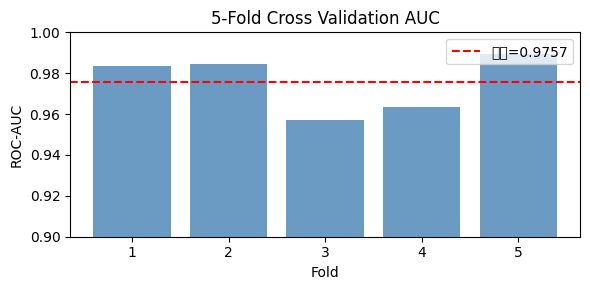

In [9]:
# Cell 8 ── 5 折交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f'各折 AUC：{cv_scores.round(4)}')
print(f'均值={cv_scores.mean():.4f}  标准差={cv_scores.std():.4f}')

# 可视化
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'均值={cv_scores.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold Cross Validation AUC')
ax.set_ylim(0.9, 1.0); ax.legend()
plt.tight_layout(); plt.show()

In [10]:
# Cell 9 ── 测试集评估
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['未完成', '完成']))

Accuracy : 0.9500
ROC-AUC  : 0.9853

              precision    recall  f1-score   support

         未完成       0.93      0.96      0.95        90
          完成       0.96      0.95      0.95       110

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



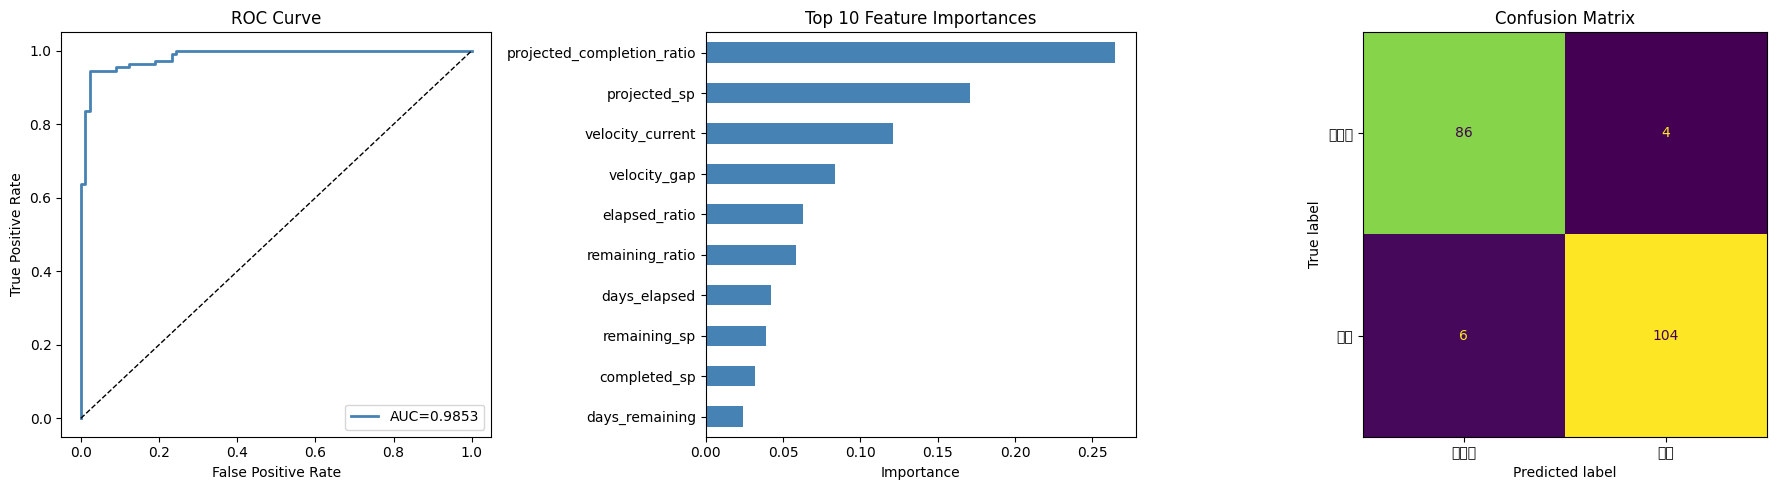

图表已保存：figures\training_summary.png


In [11]:
# Cell 10 ── 可视化（ROC + 特征重要性 + 混淆矩阵）
importances = pd.Series(model.feature_importances_, index=EXTENDED_COLS).sort_values(ascending=False)
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(loc='lower right')

# 特征重要性 Top 10
importances.head(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Feature Importances'); axes[1].set_xlabel('Importance')

# 混淆矩阵
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['未完成','完成'], ax=axes[2], colorbar=False
)
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
os.makedirs(FIGURES_DIR, exist_ok=True)
fig_path = os.path.join(FIGURES_DIR, 'training_summary.png')
plt.savefig(fig_path, dpi=120)
plt.show()
print(f'图表已保存：{fig_path}')

In [12]:
# Cell 11 ── 完整特征重要性排名
importances.reset_index().rename(columns={'index':'feature', 0:'importance'}).style.bar(
    subset=['importance'], color='#5B9BD5'
)

,feature,importance
0,projected_completion_ratio,0.264806
1,projected_sp,0.171056
2,velocity_current,0.121330
3,velocity_gap,0.083834
4,elapsed_ratio,0.062728
5,remaining_ratio,0.058157
6,days_elapsed,0.042222
7,remaining_sp,0.039349
8,completed_sp,0.032061
9,days_remaining,0.023842


In [13]:
# Cell 12 ── 保存模型产物
joblib.dump(model, MODEL_PATH)
print(f'模型已保存：{MODEL_PATH}')

with open(FEATURE_COLUMNS_PATH, 'w', encoding='utf-8') as f:
    json.dump({'feature_columns': EXTENDED_COLS}, f, ensure_ascii=False, indent=2)
print(f'特征列已保存：{FEATURE_COLUMNS_PATH}')

with open(REPORT_PATH, 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('  随机森林 Sprint 完成预测 - 训练报告\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'特征列数：{len(EXTENDED_COLS)}\n特征列：{EXTENDED_COLS}\n\n')
    f.write(f'Accuracy : {acc:.4f}\nROC-AUC  : {auc:.4f}\n\n')
    f.write('分类报告：\n')
    f.write(classification_report(y_test, y_pred, target_names=['未完成', '完成']))
    f.write('\n特征重要性：\n')
    f.write(importances.to_string())
    f.write('\n\n模型参数：\n')
    for k, v in RF_PARAMS.items():
        f.write(f'  {k}: {v}\n')
print(f'报告已保存：{REPORT_PATH}')

模型已保存：random_forest_model.pkl
特征列已保存：feature_columns.json
报告已保存：training_report.txt


In [14]:
# Cell 13 ── 推理演示（修改下方数值测试不同场景）
sample_raw = dict(
    sprint_days=14, days_elapsed=7,
    committed_sp=60.0, remaining_sp=25.0, completed_sp=35.0,
    velocity_current=5.0, velocity_avg_5=4.8, velocity_std_5=0.8,
    blocked_stories=1, attendance_rate=0.9,
    ratio_feature=0.6, ratio_bug=0.2, ratio_tech_debt=0.2,
)

# 自动计算衍生特征
s = sample_raw
days_rem = s['sprint_days'] - s['days_elapsed']
proj_sp  = s['completed_sp'] + s['velocity_current'] * max(days_rem, 0)
sample_full = {**s,
    'days_remaining':             days_rem,
    'elapsed_ratio':              s['days_elapsed'] / max(s['sprint_days'], 1),
    'remaining_ratio':            s['remaining_sp'] / max(s['committed_sp'], 1),
    'velocity_gap':               s['velocity_current'] - s['velocity_avg_5'],
    'projected_sp':               proj_sp,
    'projected_completion_ratio': proj_sp / max(s['committed_sp'], 1),
}

X_sample = np.array([[sample_full[c] for c in EXTENDED_COLS]])
prob = model.predict_proba(X_sample)[0][1]
risk_color = {'GREEN': '🟢', 'YELLOW': '🟡', 'RED': '🔴'}
risk = 'GREEN' if prob >= 0.8 else ('YELLOW' if prob >= 0.5 else 'RED')

print(f'完成概率：{prob:.4f}')
print(f'风险等级：{risk_color[risk]} {risk}')

完成概率：0.9608
风险等级：🟢 GREEN
